# earthkit-meteo: extreme events

In [1]:
import earthkit.data as ekd
from earthkit.meteo import extreme
import earthkit.plots as ekp

ds_fc = ekd.from_source("sample", "extreme_2t_fc.grib").to_xarray()
ds_fc

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    2t         (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [2]:

ds_clim = ekd.from_source("sample", "extreme_2t_clim.grib").to_xarray()
ds_clim

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    avg_2t     (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [4]:
efi = extreme.efi(ds_fc["2t"], ds_clim["avg_2t"])
efi

<xarray.DataArray '2t' (values: 421120)> Size: 3MB
array([-0.63844876, -0.63113266, -0.6209948 , ...,  0.23228553,
        0.25972762,  0.27982915], shape=(421120,))
Coordinates:
    latitude   (values) float64 3MB 89.78 89.78 89.78 ... -89.78 -89.78 -89.78
    longitude  (values) float64 3MB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
Dimensions without coordinates: values
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          kelvin
    level_type:     surface
    _earthkit:      {'message': b'GRIB\x00\x05\xa2\x01\x00\x00j\x80b\x9e\xff\...
    ek_grid_spec:   {"grid": "O320"}

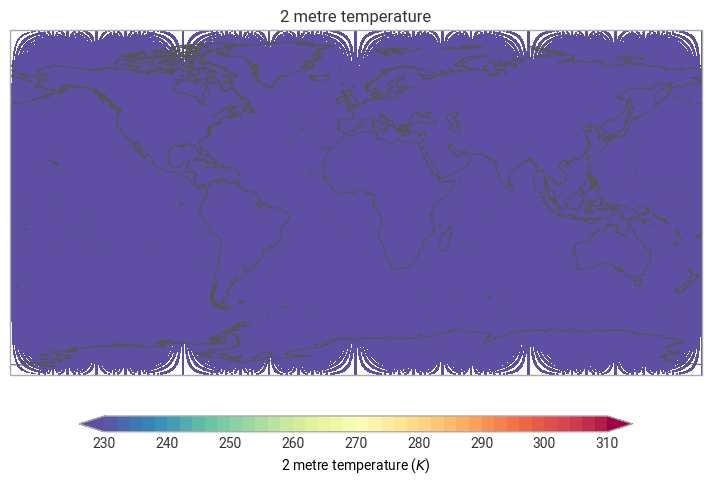

In [5]:
ekp.quickplot(efi).show()